# Lab 11: Sorting Analysis

In this notebook you'll visualize how sorting algorithms work, measure their performance, and discover why Big-O isn't the whole story.

**Before you start:** Paste your completed sort functions into the cell below.

In [2]:
"""
Lab 11: Sorting — Why Big-O Isn't the Whole Story

In this lab you will implement two sorting algorithms (bubble sort
and insertion sort), an optimized variant (short bubble sort), and
counted versions that track comparisons and data moves.

Complete the five functions marked with TODO.
Do NOT change the function signatures.

Run tests:
    pytest -v
"""


# ── TODO 1: Bubble Sort ─────────────────────────────────────────


def bubble_sort(a_list):
    """
    Sort a_list in ascending order using bubble sort.

    Makes multiple passes through the list, comparing adjacent items
    and swapping any pair that is out of order. After each pass, the
    next largest item has "bubbled" into its correct position at the end.

    Algorithm:
        1. Make n - 1 passes (outer loop, where n = len(a_list))
        2. On pass i, compare adjacent items from position 0
           up to position n - 1 - i
        3. If a_list[j] > a_list[j + 1], swap them

    Args:
        a_list: A list of comparable items.

    Returns:
        The same list, now sorted in ascending order.
    """
    n = len(a_list)
    for i in range(n - 1):
        for j in range(n - 1 - i):
            if a_list[j] > a_list[j + 1]:
                a_list[j], a_list[j + 1] = a_list[j + 1], a_list[j]
    return a_list

# ── TODO 2: Short Bubble Sort ───────────────────────────────────


def short_bubble_sort(a_list):
    """
    Sort a_list using bubble sort with early termination.

    Works exactly like bubble_sort, but tracks whether any exchanges
    happened during each pass. If a complete pass makes no exchanges,
    the list is already sorted — stop immediately.

    Hint: Use a boolean flag. Set it to False at the start of each
    pass, set it to True whenever you swap. After the pass, check it.

    Args:
        a_list: A list of comparable items.

    Returns:
        The same list, now sorted in ascending order.
    """
    n = len(a_list)
    for i in range(n - 1):
        swapped = False
        for j in range(n - 1 - i):
            if a_list[j] > a_list[j + 1]:
                a_list[j], a_list[j + 1] = a_list[j + 1], a_list[j]
                swapped = True
        if not swapped:
            break
    return a_list


# ── TODO 3: Insertion Sort ──────────────────────────────────────


def insertion_sort(a_list):
    """
    Sort a_list in ascending order using insertion sort.

    Builds a sorted region from the left side of the list. For each
    new item, shift larger items to the right to make room, then
    insert the item in its correct position.

    Algorithm:
        1. Start at position 1 (position 0 is a sorted list of one)
        2. Save the current item as current_value
        3. Walk backward through the sorted region (position i-1 down to 0):
           - If a_list[position] > current_value, shift it right
             (copy it to position + 1)
           - Otherwise, stop — you've found the insertion point
        4. Place current_value at the insertion point

    Hint: Use a while loop for the backward walk. Check
    position >= 0 FIRST in the condition — think about why the
    order matters.

    Args:
        a_list: A list of comparable items.

    Returns:
        The same list, now sorted in ascending order.
    """
    n = len(a_list)
    for i in range(1, n):
        current_value = a_list[i]
        position = i - 1
        while position >= 0 and a_list[position] > current_value:
            a_list[position + 1] = a_list[position]
            position -= 1
        a_list[position + 1] = current_value
    return a_list

# ── TODO 4: Counted Versions ────────────────────────────────────


def bubble_sort_counted(a_list):
    """
    Sort a_list using bubble sort, counting comparisons and exchanges.

    Works exactly like bubble_sort, but also counts:
    - comparisons: each time you check if a_list[j] > a_list[j+1]
    - exchanges: each time you swap two items (count the swap as 1)

    Args:
        a_list: A list of comparable items.

    Returns:
        A tuple (sorted_list, comparisons, exchanges) where:
            sorted_list: The sorted list.
            comparisons: Total number of item comparisons made.
            exchanges: Total number of swaps performed.

    Example:
        bubble_sort_counted([3, 1, 2])
        → ([1, 2, 3], 3, 2)
    """
    n = len(a_list)
    comparisons = 0
    exchanges = 0
    for i in range(n - 1):
        for j in range(n - 1 - i):
            comparisons += 1
            if a_list[j] > a_list[j + 1]:
                a_list[j], a_list[j + 1] = a_list[j + 1], a_list[j]
                exchanges += 1
    return (a_list, comparisons, exchanges)


def insertion_sort_counted(a_list):
    """
    Sort a_list using insertion sort, counting comparisons and data moves.

    Works exactly like insertion_sort, but also counts:
    - comparisons: each time you check if a_list[position] > current_value
    - data_moves: each shift (moving an item right) counts as 1,
      and the final placement of current_value counts as 1

    Args:
        a_list: A list of comparable items.

    Returns:
        A tuple (sorted_list, comparisons, data_moves) where:
            sorted_list: The sorted list.
            comparisons: Total number of item comparisons made.
            data_moves: Total number of shifts + placements.

    Example:
        insertion_sort_counted([3, 1, 2])
        → ([1, 2, 3], 3, 4)
    """

    n = len(a_list)
    comparisons = 0
    data_moves = 0
    for i in range(1, n):
        current_value = a_list[i]
        position = i - 1
        while position >= 0:
            comparisons += 1
            if a_list[position] > current_value:
                a_list[position + 1] = a_list[position]
                data_moves += 1
                position -= 1
            else:
                break
        a_list[position + 1] = current_value
        data_moves += 1
    return (a_list, comparisons, data_moves)



In [3]:
# Quick sanity check — run this to make sure your functions work
assert bubble_sort([5, 3, 1, 4, 2]) == [1, 2, 3, 4, 5], "bubble_sort failed"
assert short_bubble_sort([5, 3, 1, 4, 2]) == [1, 2, 3, 4, 5], "short_bubble_sort failed"
assert insertion_sort([5, 3, 1, 4, 2]) == [1, 2, 3, 4, 5], "insertion_sort failed"

r1, c1, e1 = bubble_sort_counted([3, 1, 2])
assert r1 == [1, 2, 3], "bubble_sort_counted failed"

r2, c2, d2 = insertion_sort_counted([3, 1, 2])
assert r2 == [1, 2, 3], "insertion_sort_counted failed"

print("All functions working!")

All functions working!


---
## Experiment 1: Watching the Mechanism

Before we measure performance, let's *see* how each algorithm sorts. The helper functions below print the list after every pass so you can watch the progress.

In [4]:
def bubble_sort_visual(a_list):
    """Bubble sort with a printout after each pass."""
    a_list = a_list[:]  # work on a copy
    n = len(a_list)
    print(f"Start:  {a_list}")
    for i in range(n - 1):
        for j in range(n - 1 - i):
            if a_list[j] > a_list[j + 1]:
                a_list[j], a_list[j + 1] = a_list[j + 1], a_list[j]
        # Show sorted vs unsorted regions
        sorted_start = n - 1 - i
        unsorted = a_list[:sorted_start]
        sorted_part = a_list[sorted_start:]
        print(f"Pass {i+1}: {unsorted} | {sorted_part}")
    return a_list


def insertion_sort_visual(a_list):
    """Insertion sort with a printout after each pass."""
    a_list = a_list[:]  # work on a copy
    n = len(a_list)
    print(f"Start:  {a_list}")
    for i in range(1, n):
        current_value = a_list[i]
        position = i - 1
        while position >= 0 and a_list[position] > current_value:
            a_list[position + 1] = a_list[position]
            position -= 1
        a_list[position + 1] = current_value
        # Show sorted vs unsorted regions
        sorted_part = a_list[:i + 1]
        unsorted = a_list[i + 1:]
        print(f"Pass {i}: {sorted_part} | {unsorted}")
    return a_list

In [6]:
test_list = [54, 26, 93, 17, 77, 31, 44, 55, 20]

print("=" * 50)
print("BUBBLE SORT")
print("=" * 50)
bubble_sort_visual(test_list)

print()
print("=" * 50)
print("INSERTION SORT")
print("=" * 50)
insertion_sort_visual(test_list)

BUBBLE SORT
Start:  [54, 26, 93, 17, 77, 31, 44, 55, 20]
Pass 1: [26, 54, 17, 77, 31, 44, 55, 20] | [93]
Pass 2: [26, 17, 54, 31, 44, 55, 20] | [77, 93]
Pass 3: [17, 26, 31, 44, 54, 20] | [55, 77, 93]
Pass 4: [17, 26, 31, 44, 20] | [54, 55, 77, 93]
Pass 5: [17, 26, 31, 20] | [44, 54, 55, 77, 93]
Pass 6: [17, 26, 20] | [31, 44, 54, 55, 77, 93]
Pass 7: [17, 20] | [26, 31, 44, 54, 55, 77, 93]
Pass 8: [17] | [20, 26, 31, 44, 54, 55, 77, 93]

INSERTION SORT
Start:  [54, 26, 93, 17, 77, 31, 44, 55, 20]
Pass 1: [26, 54] | [93, 17, 77, 31, 44, 55, 20]
Pass 2: [26, 54, 93] | [17, 77, 31, 44, 55, 20]
Pass 3: [17, 26, 54, 93] | [77, 31, 44, 55, 20]
Pass 4: [17, 26, 54, 77, 93] | [31, 44, 55, 20]
Pass 5: [17, 26, 31, 54, 77, 93] | [44, 55, 20]
Pass 6: [17, 26, 31, 44, 54, 77, 93] | [55, 20]
Pass 7: [17, 26, 31, 44, 54, 55, 77, 93] | [20]
Pass 8: [17, 20, 26, 31, 44, 54, 55, 77, 93] | []


[17, 20, 26, 31, 44, 54, 55, 77, 93]

### Experiment 1 Questions

Study the output above and answer these questions:

**Q1:** In bubble sort, where do the sorted items accumulate — the left end or the right end of the list? In insertion sort, where do they accumulate?

*Your answer: In bubble sort, it sorts on the right end and then the Insertion is on the left end


**Q2:** Watch bubble sort's first few passes. How much does the unsorted region shrink after each pass? Now watch insertion sort — how much does the sorted region grow after each pass?

*Your answer: it looks like bubble sort only does one at a time, and it looks like insertion sort does two at some points. Insertion seems a lot faster to sort things but also ends with 8 passes. interesting...


**Q3:** Which algorithm's progress is easier to follow visually? Why do you think that is?

*Your answer: bubble sort seems to be easier to follow as it just goes through one at a time.


---
## Experiment 2: The Comparison Race

Now let's measure. We'll run both counted sort functions on randomly generated lists of increasing size and plot comparisons and data moves separately.

In [10]:
import random
import matplotlib.pyplot as plt

sizes = [100, 500, 1000, 5000]
bubble_comps = []
bubble_moves = []
insertion_comps = []
insertion_moves = []

for n in sizes:
    data = list(range(n))
    random.shuffle(data)

    _, bc, be = bubble_sort_counted(data[:])
    _, ic, im = insertion_sort_counted(data[:])

    bubble_comps.append(bc)
    bubble_moves.append(be)
    insertion_comps.append(ic)
    insertion_moves.append(im)

    print(f"n={n:>5}: Bubble comps={bc:>10,}  exchanges={be:>10,}  |  Insertion comps={ic:>10,}  data_moves={im:>10,}")

n=  100: Bubble comps=     4,950  exchanges=     2,320  |  Insertion comps=     2,418  data_moves=     2,419
n=  500: Bubble comps=   124,750  exchanges=    59,611  |  Insertion comps=    60,105  data_moves=    60,110
n= 1000: Bubble comps=   499,500  exchanges=   252,210  |  Insertion comps=   253,203  data_moves=   253,209
n= 5000: Bubble comps=12,497,500  exchanges= 6,289,292  |  Insertion comps= 6,294,284  data_moves= 6,294,291


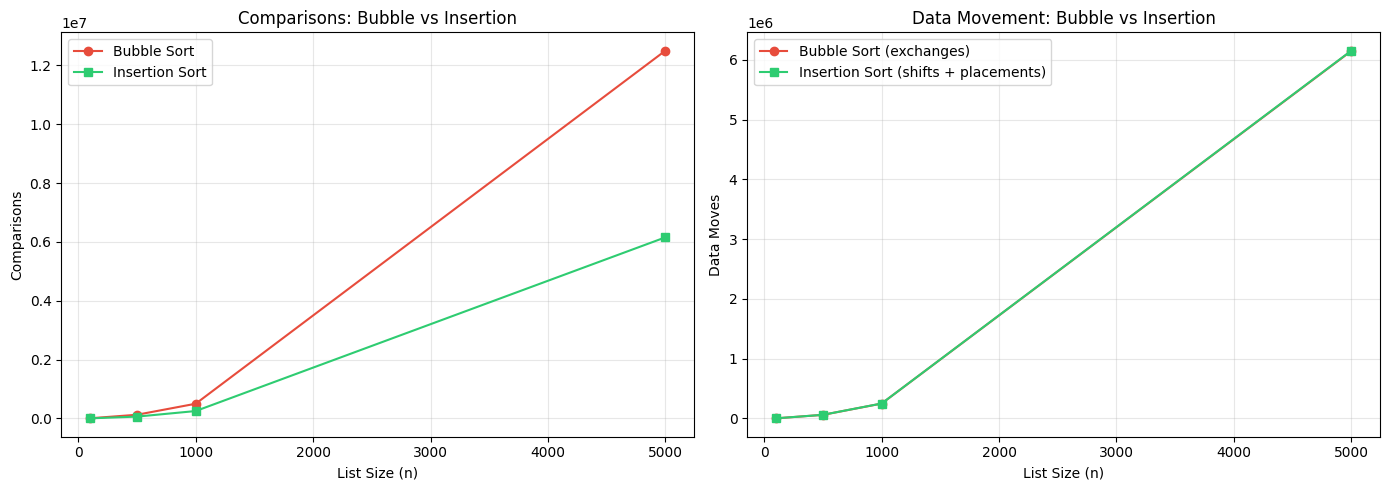

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Comparisons
ax1.plot(sizes, bubble_comps, 'o-', label='Bubble Sort', color='#e74c3c')
ax1.plot(sizes, insertion_comps, 's-', label='Insertion Sort', color='#2ecc71')
ax1.set_xlabel('List Size (n)')
ax1.set_ylabel('Comparisons')
ax1.set_title('Comparisons: Bubble vs Insertion')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Data moves
ax2.plot(sizes, bubble_moves, 'o-', label='Bubble Sort (exchanges)', color='#e74c3c')
ax2.plot(sizes, insertion_moves, 's-', label='Insertion Sort (shifts + placements)', color='#2ecc71')
ax2.set_xlabel('List Size (n)')
ax2.set_ylabel('Data Moves')
ax2.set_title('Data Movement: Bubble vs Insertion')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Experiment 2 Questions

**Q1:** Look at the comparisons graph. Do bubble sort and insertion sort make roughly the same number of comparisons, or is one consistently higher? Does this match what you'd expect from their shared O(n^2) classification?

*Your answer: as n grows, bubble sort is going to have a lot more comparisons than insertion sort. which is kind of interesting because they share the same n^2.


**Q2:** Now look at the data moves graph. What do you see? Which algorithm moves data more efficiently?

*Your answer: it looks like bubble sort move the data a little bit more efficently byt not by much!


**Q3:** If comparisons are roughly equal but data movement is very different, what does that tell you about using Big-O alone to predict real-world performance?

*Your answer: it is not 100% effective to calulate and looks at preformance


---
## Experiment 3: Best Case, Worst Case

Not all inputs are created equal. Let's see how each algorithm handles the best case (already sorted), worst case (reverse sorted), and average case (random).

In [11]:
n = 1000

already_sorted = list(range(n))
reverse_sorted = list(range(n - 1, -1, -1))
random_list = list(range(n))
random.shuffle(random_list)

cases = {
    "Already sorted": already_sorted,
    "Reverse sorted": reverse_sorted,
    "Random": random_list,
}

print(f"{'Case':<20} {'Algorithm':<15} {'Comparisons':>12} {'Data Moves':>12}")
print("-" * 62)

for case_name, data in cases.items():
    _, bc, be = bubble_sort_counted(data[:])
    _, ic, im = insertion_sort_counted(data[:])
    print(f"{case_name:<20} {'Bubble':<15} {bc:>12,} {be:>12,}")
    print(f"{'':<20} {'Insertion':<15} {ic:>12,} {im:>12,}")
    print()

Case                 Algorithm        Comparisons   Data Moves
--------------------------------------------------------------
Already sorted       Bubble               499,500            0
                     Insertion                999          999

Reverse sorted       Bubble               499,500      499,500
                     Insertion            499,500      500,499

Random               Bubble               499,500      251,050
                     Insertion            252,046      252,049



### Experiment 3 Questions

**Q1:** Which sort benefits the most from already-sorted input? Look at both comparisons and data moves — does either drop dramatically?

*Your answer: Insertion had dramaticly less comparison than bubble!


**Q2:** On reverse-sorted input, which sort performs worst? Why does that specific input cause the most work for that algorithm?

*Your answer: Bubble does slightly better but very little. because it is in a different sort than what the algorithim needs, it is going to do worst case and go through everything.


**Q3:** If you knew your data was *almost* sorted — say, one or two items out of place — which algorithm would you choose: bubble sort, short bubble sort, or insertion sort? Why? Think about your short bubble implementation — how would it handle nearly-sorted input?

*Your answer: I'd probably do insertion because it doesnt have to keep going through eveyrthing!
